In [27]:
import numpy as np
import matplotlib.pyplot as plt
from Classes.Problem import Problem
from Classes.Algorithm import VariableNeighborhoodSearch
from Classes.Neighborhood import Swap, Reversion, Insertion, Slide

from scipy.stats import kruskal, shapiro
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [4]:
def convergence_analysis(operators, evaluation_limits, runs):
    data = Problem()
    data.loadFile("data/data.npz")
    
    best_FX_values = np.zeros((len(evaluation_limits), runs))

    for i, max_eval in enumerate(evaluation_limits):
        for j in range(runs):
            # Rodando só para o estocástico
            vns = VariableNeighborhoodSearch(operators, max_eval, initialization=1)
            solution = vns.solve(data)
            best_FX_values[i, j] = solution.FX
    
    np.savez("data/convergence_analysis_results.npz", best_FX_values=best_FX_values)

In [11]:
evaluation_limits = [50000, 100000, 125000, 150000, 175000, 200000]
operators = [Swap(5), Reversion(4), Insertion(3), Slide(2)]
runs = 30

convergence_analysis(operators, evaluation_limits, runs)

Initial FX: 9529690.232989395
Final solution: 7808245.230287222
Initial FX: 11285002.0442446
Final solution: 7412752.989810258
Initial FX: 11313459.686356116
Final solution: 7375855.950176503
Initial FX: 9174602.206514172
Final solution: 7451311.695552688
Initial FX: 11483322.313978313
Final solution: 7375855.950176503
Initial FX: 10872934.15425199
Final solution: 7699308.257417355
Initial FX: 11032430.232108599
Final solution: 7411749.686398754
Initial FX: 11707781.522822343
Final solution: 7461460.838969169
Initial FX: 10756874.028247
Final solution: 7432645.777974365
Initial FX: 9063549.852979366
Final solution: 7449573.935995293
Initial FX: 9071786.50186126
Final solution: 7462312.576831346
Initial FX: 11872381.790709127
Final solution: 7451311.695552688
Initial FX: 11669457.32932393
Final solution: 7411269.725740193
Initial FX: 10934140.028488709
Final solution: 7375855.950176503
Initial FX: 10031857.457236852
Final solution: 7432645.777974365
Initial FX: 10011519.428508876
Final 

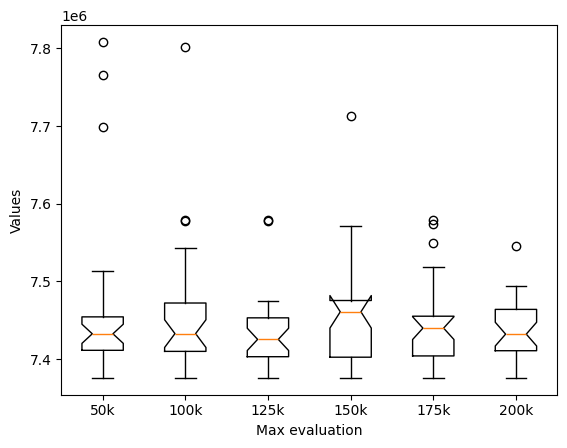

In [14]:
def plot_boxplots(filename, evaluation_limits):
    data = np.load(filename)
    outer_array = data[data.files[0]]

    plt.figure()
    plt.boxplot(outer_array.T, notch=True)
    
    plt.xticks(np.arange(1, len(evaluation_limits) + 1), evaluation_limits)
    
    plt.xlabel("Max evaluation")
    plt.ylabel("Values")
    plt.show()

filename = 'convergence_analysis_results.npz'
evaluation_limits = ['50k', '100k', '125k', '150k', '175k', '200k']  
plot_boxplots(filename, evaluation_limits)


In [26]:
filename = 'data/convergence_analysis_results.npz'
data = np.load(filename)
data = data[data.files[0]]
a = data[0, :]
b = data[1, :]
c = data[2, :]
d = data[3, :]
e = data[4, :]
f = data[5, :]

In [29]:
# Shapiro-Wilk test
# H0: the data was drawn from a normal distribution
print(shapiro(data))

ShapiroResult(statistic=0.7579667123517886, pvalue=6.294065686461529e-16)


In [30]:
# Load the convergence analysis results
results = np.load("data/convergence_analysis_results.npz")
best_FX_values = results["best_FX_values"]

# Perform Kruskal-Wallis test
H_statistic, p_value = kruskal(*best_FX_values)

# Print Kruskal-Wallis test results
print("Kruskal-Wallis test results:")
print("H-statistic:", H_statistic)
print("p-value:", p_value)

# If the p-value is significant, proceed with post-hoc tests
if p_value < 0.05:
    print("\nPost-hoc test (Conover-Iman test):")
    posthoc = pairwise_tukeyhsd(np.ravel(best_FX_values), np.repeat(evaluation_limits, runs))
    print(posthoc)
else:
    print("No significant differences found between evaluation limits.")

Kruskal-Wallis test results:
H-statistic: 2.7379811818479665
p-value: 0.7403035366607984
No significant differences found between evaluation limits.
